# Análisis modular del TP1

Este notebook ejecuta el flujo de análisis por celdas y es compatible con VS Code, Jupyter y Google Colab.

**Archivo de entrada:** `datos_TP1_2025.csv`

## 1. Crear el notebook y seleccionar el kernel

En VS Code o Colab, seleccioná un kernel de Python válido antes de ejecutar las celdas. Los resultados quedarán embebidos en este archivo `.ipynb`.

## 2. Instalar y validar dependencias

Ejecutá esta celda solo si el entorno no tiene `pandas` o `matplotlib` instalados. En Google Colab normalmente ya están disponibles.

In [188]:
%pip install plotly nbformat statsmodels

You should consider upgrading via the '/Users/diegorojas/Documents/github projects/aa-tp-1/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [189]:
import sys
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss, confusion_matrix, f1_score
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from functions.utils import *
from functions.eda import *
from functions.training import *

## 3. Cargar los datos

La ruta relativa funciona tanto en la carpeta local del proyecto como después de subir el archivo a Colab.

In [190]:
from pathlib import Path

DATA_PATH = Path("../outputs/dataset_binario.pkl")
OUTPUT_DIR = Path("../outputs")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró: {DATA_PATH.resolve()}")

dataset = cargar_pickle(DATA_PATH)
print(f"Dataset cargado: {dataset.shape[0]:,} filas y {dataset.shape[1]} columnas")
dataset.head()

Archivo pickle cargado desde: /Users/diegorojas/Documents/github projects/aa-tp-1/outputs/dataset_binario.pkl
Dataset cargado: 40,236 filas y 52 columnas


,Estudios_máximos_antes_de_la_inscripción,estado_civil,modo_aplicacion,sexo,desplazado,target,carrera,asistencia,cualificacion_promedio,puntaje_ingreso,...,promedio_cant_evaluaciones_semestres,ratio_aprobadas_inscritas,ingresos_padre_nivel,ingresos_madre_nivel,ingresos_familia_nivel,demanda_cog_padre_nivel,demanda_cog_madre_nivel,demanda_cog_familia_nivel,target_num,es_desercion
0,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,Graduado,Turismo,Diurna,65,61,...,7.00,0.92,1,1,1.00,1,1,1.00,0,0
1,Educación Secundaria,Soltero,Acceso por Normativa Específica,Femenino,No,Desertor,Enfermería,Diurna,67,58,...,12.50,0.00,1,1,1.00,1,1,1.00,1,1
5,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,Graduado,Enfermería,Diurna,62,59,...,8.00,1.00,3,3,3.00,3,3,3.00,0,0
6,Educación Secundaria,Casado,Acceso por Normativa Específica,Femenino,No,Graduado,Servicio Social,Nocturna,67,66,...,11.50,0.86,1,1,1.00,1,1,1.00,0,0
7,Educación Secundaria,Soltero,Acceso General,Femenino,Sí,Desertor,Periodismo y Comunicación,Diurna,80,69,...,9.00,0.75,1,1,1.00,1,1,1.00,1,1


In [173]:
dataset.columns

Index(['Estudios_máximos_antes_de_la_inscripción', 'estado_civil',
       'modo_aplicacion', 'sexo', 'desplazado', 'target', 'carrera',
       'asistencia', 'cualificacion_promedio', 'puntaje_ingreso',
       'necesidades_educativas_especiales', 'tiene_deuda', 'matricula_al_dia',
       'posee_beca', 'edad_inscripcion', 'estudiante_internacional',
       'uc_inscritos_primer_semestre', 'cant_eval_primer_semestre',
       'uc_aprobadas_primer_semestre', 'nota_promedio_primer_semestre',
       'uc_inscritos_segundo_semestre', 'cant_eval_segundo_semestre',
       'uc_aprobadas_segundo_semestre', 'nota_promedio_segundo_semestre',
       'Demanda_Cog_Padre', 'Demanda_Cog_Madre', 'Ingresos_Padre',
       'Ingresos_Madre', 'macro_categoria_estado_civil',
       'macro_categoria_estudios_maximos', 'macro_categoria_carrera',
       'es_masculino', 'es_desplazado', 'es_asistencia_diurna', 'es_deudor',
       'es_moroso', 'es_becado', 'es_estudiante_internacional',
       'tiene_necesidades_educa

In [5]:
categorical_features = [
    'Estudios_máximos_antes_de_la_inscripción',
    'estado_civil',
    'modo_aplicacion',
    'carrera',
]

numeric_features = ['cualificacion_promedio', 'puntaje_ingreso',
       'edad_inscripcion', 'tiene_necesidades_educativas_especiales',
       'es_masculino', 'es_desplazado',
       'es_asistencia_diurna', 'es_deudor', 'es_moroso', 'es_becado',
       'es_estudiante_internacional', 'promedio_notas_semestres',
       'promedio_uc_inscritos_semestres', 'promedio_uc_aprobadas_semestres', 'ratio_aprobadas_inscritas',
       'promedio_cant_evaluaciones_semestres', 'ingresos_familia_nivel',
       'demanda_cog_familia_nivel']

X_features = categorical_features + numeric_features
Y_features = ['es_desercion']

- Dividir el dataset (train y test)

In [38]:
# X -> atributos, y -> etiquetas
X = dataset[X_features]
y = dataset[Y_features]

# dividiendo X, y en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, train_size=0.8, test_size=0.2, stratify=y)

# el encoder se ajusta solo con X_train (evita fuga de datos) y con handle_unknown='ignore'
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ],
    remainder="passthrough",
)

- Hacemos optimización de hiper-parámetros mediante validación cruzada usando la métrica de f1-score para diversos modelos: regresión logística, SVM, arboles de decisión y random forest. Luego seleccionamos los mejores hiper-parámetros para cada modelo y re-entrenamos usando todo el dataset de entrenamiento.

In [39]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Estrategia de validación cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_train_1d = y_train.values.ravel()

# -----------------------------------------------------------------------------
# 1. Logistic Regression
print("\nTuning Logistic Regression...")

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver="saga", random_state=42, max_iter=3000)),
])

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

param_grid_lr = [
    # Lasso y Ridge no requieren l1_ratio
    {
        "model__penalty": ["l1", "l2"],
        "model__C": C_values,
    },
    # Elastic Net requiere l1_ratio
    {
        "model__penalty": ["elasticnet"],
        "model__C": C_values,
        "model__l1_ratio": [0.1, 0.5, 0.9],
    },
]

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_lr.fit(X_train, y_train_1d)

best_lr = grid_lr.best_estimator_
print(f"Best params for Logistic Regression: {grid_lr.best_params_}")
print(f"Best f1-macro score for Logistic Regression (CV): {grid_lr.best_score_:.4f}")

# -----------------------------------------------------------------------------
# 2. SVM lineal
print("\nTuning SVM (Linear Kernel)...")

pipe_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=42, probability=True)),
])

param_grid_svm = {"model__C": [0.1, 1, 10, 100]}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_svm.fit(X_train, y_train_1d)

best_svm = grid_svm.best_estimator_
print(f"Best C for SVM: {grid_svm.best_params_['model__C']}")
print(f"Best f1-macro score for SVM (CV): {grid_svm.best_score_:.4f}")

# -----------------------------------------------------------------------------
# 3. KNN
print("\nTuning KNN...")

pipe_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier()),
])

param_grid_knn = {"model__n_neighbors": [3, 5, 7, 9, 11, 13, 15]}

grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_knn.fit(X_train, y_train_1d)

best_knn = grid_knn.best_estimator_
print(f"Best n_neighbors for KNN: {grid_knn.best_params_['model__n_neighbors']}")
print(f"Best f1-macro score for KNN (CV): {grid_knn.best_score_:.4f}")

# -----------------------------------------------------------------------------
# 4. Random Forest
print("\nTuning Random Forest...")

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

param_grid_rf = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_rf.fit(X_train, y_train_1d)

best_rf = grid_rf.best_estimator_
print(f"Best params for Random Forest: {grid_rf.best_params_}")
print(f"Best f1-macro score for Random Forest (CV): {grid_rf.best_score_:.4f}")

# -----------------------------------------------------------------------------
# 5. Decision Tree
print("\nTuning Decision Tree...")

pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42)),
])

param_grid_dt = {
    "model__max_depth": [None, 3, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    pipe_dt,
    param_grid_dt,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_dt.fit(X_train, y_train_1d)

best_dt = grid_dt.best_estimator_
print(f"Best params for Decision Tree: {grid_dt.best_params_}")
print(f"Best f1-macro score for Decision Tree (CV): {grid_dt.best_score_:.4f}")

# -----------------------------------------------------------------------------
# 6. Gradient Boosting
print("\nTuning Gradient Boosting...")

pipe_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42)),
])

param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0],
}

grid_gb = GridSearchCV(
    pipe_gb,
    param_grid_gb,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_gb.fit(X_train, y_train_1d)

best_gb = grid_gb.best_estimator_
print(f"Best params for Gradient Boosting: {grid_gb.best_params_}")
print(f"Best f1-macro score for Gradient Boosting (CV): {grid_gb.best_score_:.4f}")

# Modelos finales reentrenados automáticamente sobre todo X_train
models = {
    "Logistic Regression": best_lr,
    "SVM": best_svm,
    "KNN": best_knn,
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "Gradient Boosting": best_gb,
}


Tuning Logistic Regression...


KeyboardInterrupt: 

- Generar un ensable con varios modelos entrenados en el paso anterior

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("logistic_regression", best_lr),
        ("svm", best_svm),
        ("random_forest", best_rf),
    ],
    voting="soft",
    n_jobs=-1,
)

voting_model.fit(X_train, y_train.values.ravel())
models["Voting (soft)"] = voting_model

print("Ensamble Voting (soft) entrenado y agregado a `models`.")

Ensamble Voting (soft) entrenado y agregado a `models`.


- Guardar el resultado de los modelos entrenados

In [ ]:
MODELS_DIR = Path("../outputs/modelos/binario/training")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, model in models.items():

    filename = MODELS_DIR / f"{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"Guardado: {filename}")

# También guardamos el diccionario completo por conveniencia
joblib.dump(models, MODELS_DIR / "todos_los_modelos.pkl")
print(f"\nGuardado diccionario completo: {MODELS_DIR / 'todos_los_modelos.pkl'}")

Guardado: ../outputs/modelos/training/logistic_regression.pkl
Guardado: ../outputs/modelos/training/svm.pkl
Guardado: ../outputs/modelos/training/knn.pkl
Guardado: ../outputs/modelos/training/random_forest.pkl
Guardado: ../outputs/modelos/training/decision_tree.pkl
Guardado: ../outputs/modelos/training/gradient_boosting.pkl
Guardado: ../outputs/modelos/training/voting_(soft).pkl

Guardado diccionario completo: ../outputs/modelos/training/todos_los_modelos.pkl


In [161]:
archivo = "../outputs/modelos/binario/training/todos_los_modelos.pkl"
model = joblib.load(archivo)

In [162]:
model

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('onehot',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore'),
                                                   ['Estudios_máximos_antes_de_la_inscripción',
                                                    'estado_civil',
                                                    'modo_aplicacion',
                                                    'macro_categoria_carrera'])])),
                 ('model',
                  LogisticRegression(C=1, max_iter=3000, penalty='l1',
                                     random_state=42, solver='saga'))]),
 'SVM': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('onehot'

- Creamos un gráfico comparando el performance según el f1-score en todos los modelos entrenados en el dataset de test

Evaluating models on the test set...

--- Logistic Regression ---
Accuracy: 0.9409
F1-Macro Score: 0.9383


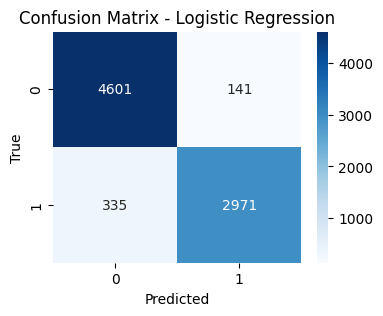


--- SVM ---
Accuracy: 0.9427
F1-Macro Score: 0.9403


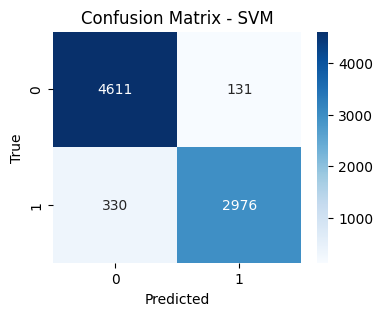


--- KNN ---
Accuracy: 0.9182
F1-Macro Score: 0.9142


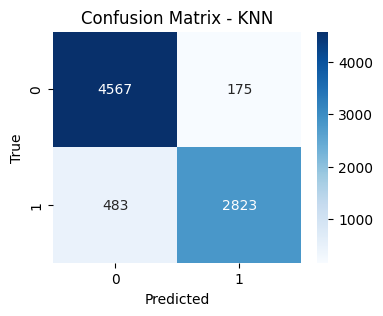


--- Random Forest ---
Accuracy: 0.9407
F1-Macro Score: 0.9381


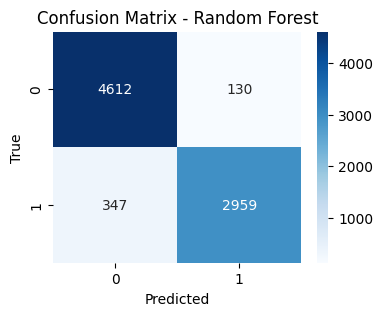


--- Decision Tree ---
Accuracy: 0.9366
F1-Macro Score: 0.9338


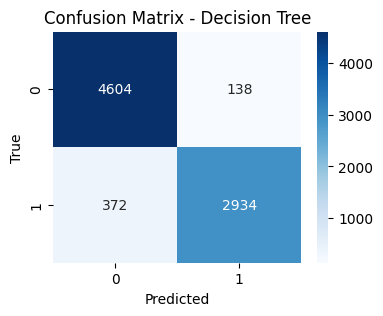


--- Gradient Boosting ---
Accuracy: 0.9428
F1-Macro Score: 0.9404


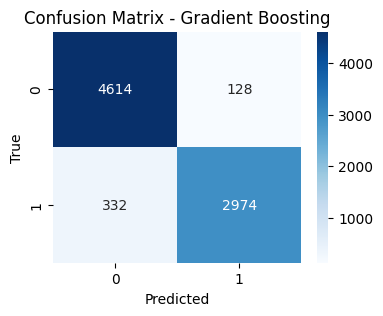


--- Voting (soft) ---
Accuracy: 0.9418
F1-Macro Score: 0.9394


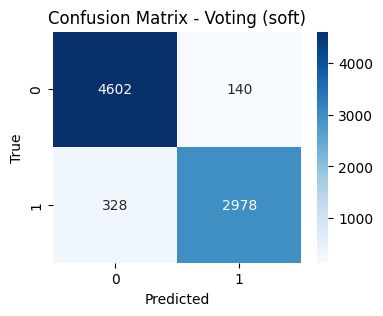


--- Model Performance Summary ---
                     Accuracy  F1-Macro  Precision-Macro
Model                                                   
Logistic Regression  0.940855  0.938325         0.943411
SVM                  0.942719  0.940253         0.945525
KNN                  0.918241  0.914212         0.922992
Random Forest        0.940731  0.938120         0.943971
Decision Tree        0.936630  0.933779         0.940160
Gradient Boosting    0.942843  0.940367         0.945806
Voting (soft)        0.941849  0.939381         0.944284


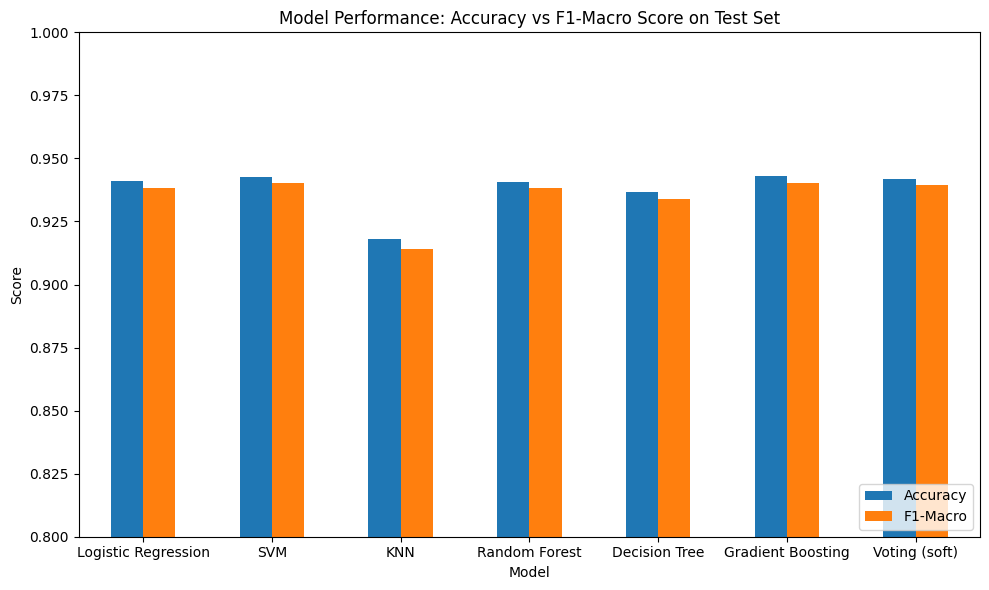

In [ ]:
results = []

print("Evaluating models on the test set...")
for name, model in models.items():
    y_pred_eval = model.predict(X_test)
    y_true = y_test

    accuracy = accuracy_score(y_true, y_pred_eval)
    f1_macro = f1_score(y_true, y_pred_eval, average='macro')

    # Calculate precision for each class and then macro average
    precision_macro = precision_score(y_true, y_pred_eval, average='macro')

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-Macro': f1_macro,
        'Precision-Macro': precision_macro
    })

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Macro Score: {f1_macro:.4f}")

    # Confusion Matrix
    cm_model = confusion_matrix(y_true, y_pred_eval)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


results_df = pd.DataFrame(results)
print("\n--- Model Performance Summary ---")
print(results_df.set_index('Model'))

# Plotting Accuracy and F1-Macro Scores
fig, ax = plt.subplots(figsize=(10, 6))
results_df.set_index('Model')[['Accuracy', 'F1-Macro']].plot(kind='bar', ax=ax, rot=0)
ax.set_title('Model Performance: Accuracy vs F1-Macro Score on Test Set')
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Regresión Logística - Modelo Explicativo
1. Curva de Complejidad - Lasso (L1)
2. Evolución de los coeficientes del modelo para diferentes niveles de complejidad
3. Coeficientes ordenados por impacto
 

In [191]:
from sklearn.preprocessing import StandardScaler

categorical_features = [
    'macro_categoria_estudios_maximos',
    'macro_categoria_estado_civil',
    'macro_categoria_carrera',
]

numeric_features = ['puntaje_ingreso',
       'edad_inscripcion', 'tiene_necesidades_educativas_especiales',
       'es_masculino', 'es_moroso', 'es_becado',
       'es_estudiante_internacional', 'promedio_notas_semestres', 'ratio_aprobadas_inscritas',
       'promedio_cant_evaluaciones_semestres', 'ingresos_familia_nivel',
        ]

X_features = categorical_features + numeric_features
Y_features = ['es_desercion']

# X -> atributos, y -> etiquetas
X = dataset[X_features]
y = dataset[Y_features]

# dividiendo X, y en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, train_size=0.8, test_size=0.2, stratify=y)

# el encoder y el scaler se ajustan solo con X_train (evita fuga de datos)
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
        ("scaler", StandardScaler(), numeric_features),
    ],
    remainder="passthrough",
)

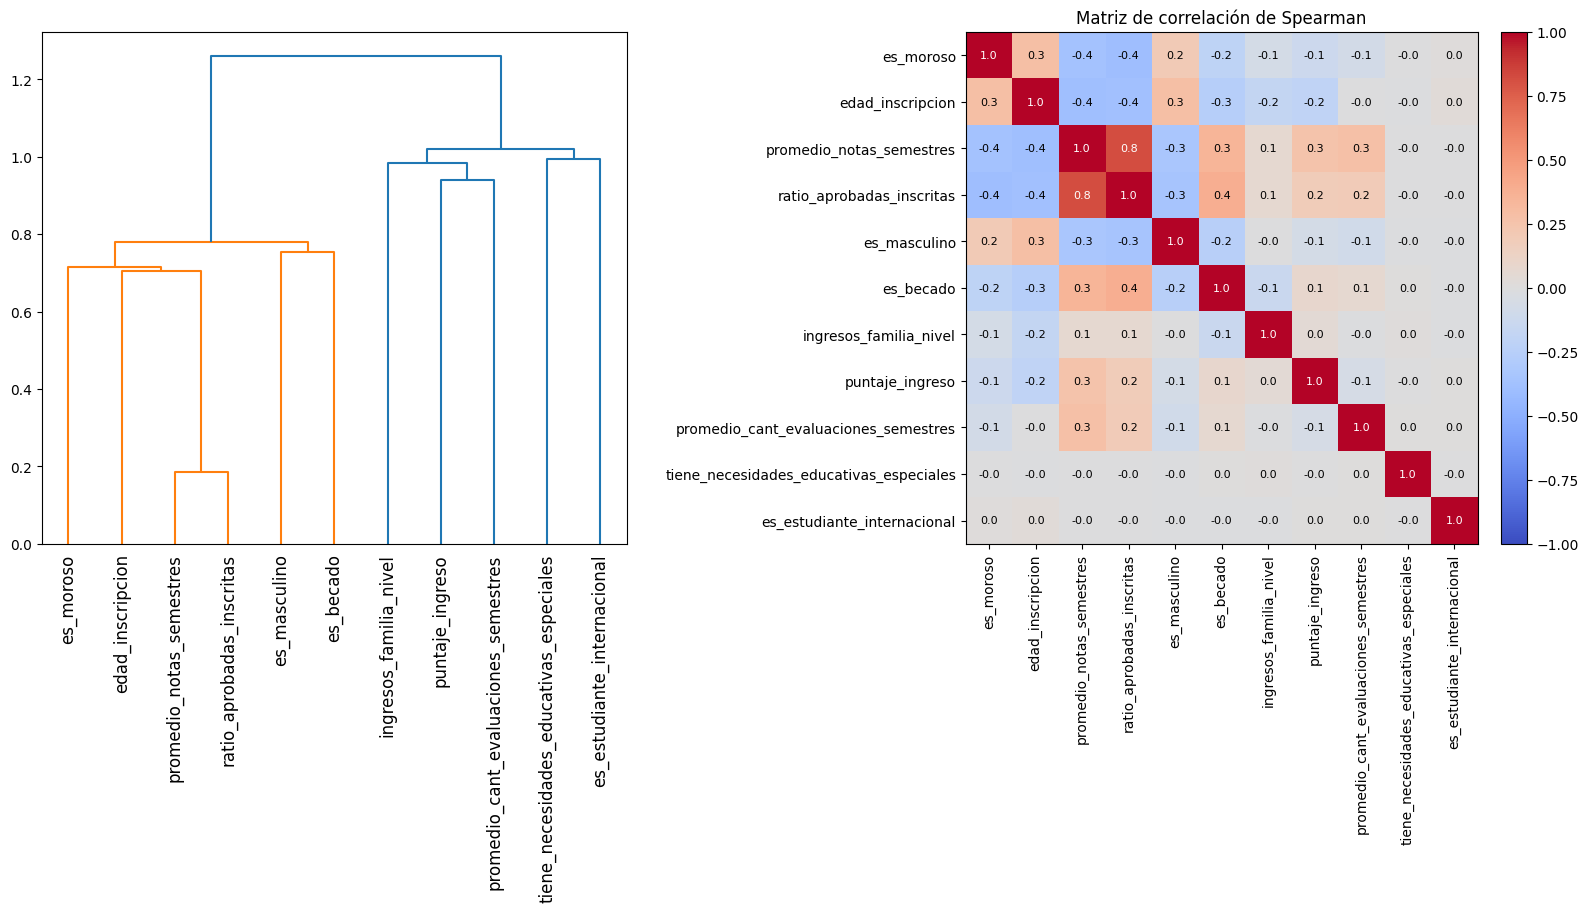

In [177]:
fig, (ax1, ax2) = graficar_clustering_correlacion(
    dataset,
    numeric_features,
)
plt.show()

In [178]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Estrategia de validación cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_train_1d = y_train.values.ravel()

# -----------------------------------------------------------------------------
# 1. Logistic Regression
print("\nTuning Logistic Regression...")

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(solver="saga", random_state=42, max_iter=3000)),
])

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

param_grid_lr = [
    # Lasso y Ridge no requieren l1_ratio
    {
        "model__penalty": ["l1", "l2"],
        "model__C": C_values,
    },
    # Elastic Net requiere l1_ratio
    {
        "model__penalty": ["elasticnet"],
        "model__C": C_values,
        "model__l1_ratio": [0.1, 0.5, 0.9],
    },
]

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv_strategy,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_lr.fit(X_train, y_train_1d)

best_lr = grid_lr.best_estimator_
print(f"Best params for Logistic Regression: {grid_lr.best_params_}")
print(f"Best f1-macro score for Logistic Regression (CV): {grid_lr.best_score_:.4f}")


# Modelos finales reentrenados automáticamente sobre todo X_train
lr_model = {
    "Logistic Regression": best_lr
}


Tuning Logistic Regression...


Best params for Logistic Regression: {'model__C': 100, 'model__penalty': 'l1'}
Best f1-macro score for Logistic Regression (CV): 0.9344


In [129]:
MODELS_DIR = Path("../outputs/modelos/binario/training-explicativo")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name, model in lr_model.items():

    filename = MODELS_DIR / f"{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, filename)
    print(f"Guardado: {filename}")

# También guardamos el diccionario completo por conveniencia
joblib.dump(lr_model, MODELS_DIR / "todos_los_modelos.pkl")
print(f"\nGuardado diccionario completo: {MODELS_DIR / 'todos_los_modelos.pkl'}")

Guardado: ../outputs/modelos/binario/training-explicativo/logistic_regression.pkl

Guardado diccionario completo: ../outputs/modelos/binario/training-explicativo/todos_los_modelos.pkl


In [192]:
# Activar/desactivar el uso de la métrica compuesta.
INCLUIR_INDICE_RENDIMIENTO = True
NOMBRE_INDICE = "indice_rendimiento_academico"
COLUMNAS_INDICE = ["promedio_notas_semestres", "ratio_aprobadas_inscritas"]

if INCLUIR_INDICE_RENDIMIENTO:
    # Calcular los parámetros solo con entrenamiento y reutilizarlos en test.
    metricas_train = dataset.loc[X_train.index, COLUMNAS_INDICE]
    metricas_test = dataset.loc[X_test.index, COLUMNAS_INDICE]

    media_indice = metricas_train.mean()
    desvio_indice = metricas_train.std().replace(0, 1)

    indice_train = ((metricas_train - media_indice) / desvio_indice).mean(axis=1)
    indice_test = ((metricas_test - media_indice) / desvio_indice).mean(axis=1)

    # Sustituir las variables originales por la métrica consolidada.
    X_train = X_train.drop(columns=COLUMNAS_INDICE, errors="ignore").copy()
    X_test = X_test.drop(columns=COLUMNAS_INDICE, errors="ignore").copy()

    X_train[NOMBRE_INDICE] = indice_train
    X_test[NOMBRE_INDICE] = indice_test

    assert not set(COLUMNAS_INDICE).intersection(X_train.columns)
    assert not set(COLUMNAS_INDICE).intersection(X_test.columns)

# Actualizar las columnas numéricas del preprocesador.
numeric_features_model = [
    col for col in numeric_features
    if col not in COLUMNAS_INDICE and col in X_train.columns
]
if INCLUIR_INDICE_RENDIMIENTO:
    numeric_features_model.append(NOMBRE_INDICE)

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
        ("scaler", StandardScaler(), numeric_features_model),
    ],
    remainder="passthrough",
)

# Ajustar el pipeline completo con los datos de entrenamiento.
classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=0.1,
        penalty="l1",
        solver="liblinear",
        random_state=42,
        max_iter=1000,
    )),
])

classifier.fit(X_train, y_train.values.ravel())

# Evaluar una sola vez en test.
y_pred = classifier.predict(X_test)
print(classification_report(y_test.values.ravel(), y_pred))


              precision    recall  f1-score   support

           0       0.92      0.97      0.94      4742
           1       0.95      0.88      0.91      3306

    accuracy                           0.93      8048
   macro avg       0.93      0.92      0.93      8048
weighted avg       0.93      0.93      0.93      8048



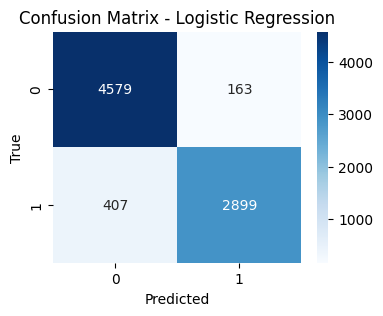

In [194]:
    # Confusion Matrix
    cm_model = confusion_matrix(y_test.values.ravel(), y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

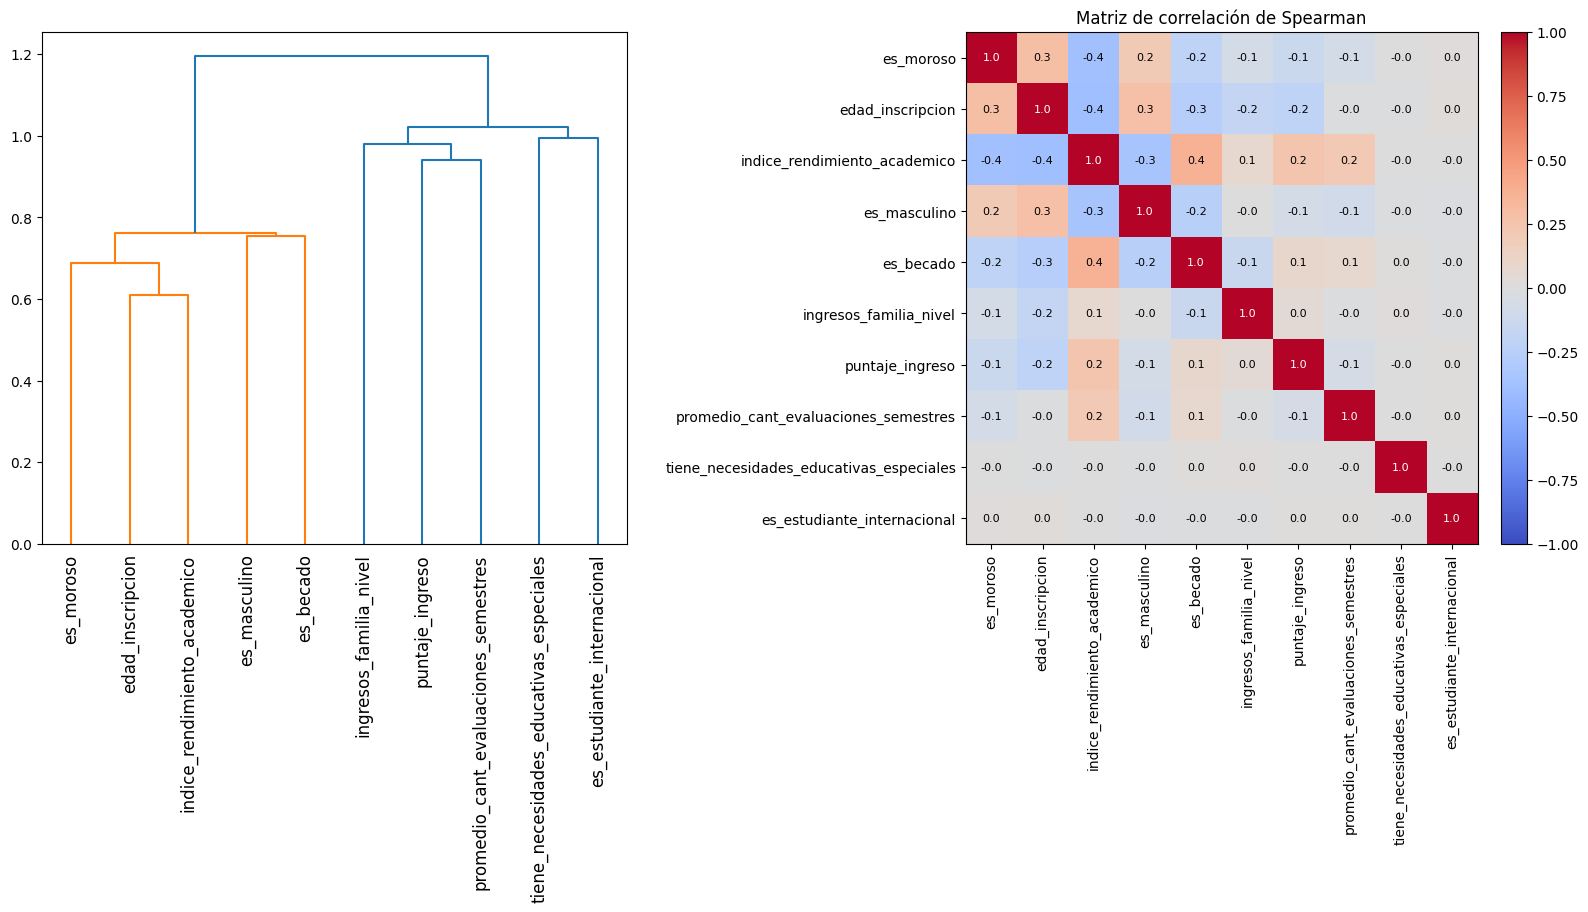

In [159]:
fig, (ax1, ax2) = graficar_clustering_correlacion(
    X_train,
    X_train.select_dtypes(include=['number']).columns
)
plt.show()

In [182]:
from sklearn.metrics import f1_score
import plotly.graph_objects as go

# C es el inverso de la fuerza de regularización: valores chicos = más regularización
C_values = np.logspace(-4, 4, 30)

# Curva de complejidad: F1-macro en train y test para cada C con regularización L1 (Lasso)
preprocessor_fit = classifier.named_steps["preprocessor"]
X_train_transformed = preprocessor_fit.transform(X_train)
X_test_transformed = preprocessor_fit.transform(X_test)
y_test_1d = y_test.values.ravel()

f1_train_lasso = []
f1_test_lasso = []

for C in C_values:
    modelo_l1 = LogisticRegression(penalty="l1", solver="liblinear", C=C, random_state=42, max_iter=1000)
    modelo_l1.fit(X_train_transformed, y_train_1d)

    f1_train_lasso.append(f1_score(y_train_1d, modelo_l1.predict(X_train_transformed), average="macro"))
    f1_test_lasso.append(f1_score(y_test_1d, modelo_l1.predict(X_test_transformed), average="macro"))

fig_complejidad = go.Figure()
fig_complejidad.add_trace(go.Scatter(
    x=C_values, y=f1_train_lasso, mode="lines+markers", name="Train",
    hovertemplate="Train<br>C=%{x:.4g}<br>F1-macro=%{y:.4f}<extra></extra>",
))
fig_complejidad.add_trace(go.Scatter(
    x=C_values, y=f1_test_lasso, mode="lines+markers", name="Test",
    hovertemplate="Test<br>C=%{x:.4g}<br>F1-macro=%{y:.4f}<extra></extra>",
))
fig_complejidad.update_layout(
    title="Curva de complejidad - Regularización Lasso (L1)",
    xaxis_title="C (a menor C, mayor regularización)",
    yaxis_title="F1-macro",
    xaxis_type="log",
    width=1000, height=650,
)
fig_complejidad.show()

In [183]:
# Evolución de los coeficientes para distintos niveles de regularización (Lasso L1 y Ridge L2)
feature_names = preprocessor_fit.get_feature_names_out()

coefs_lasso = []
coefs_ridge = []

for C in C_values:
    modelo_l1 = LogisticRegression(penalty="l1", solver="liblinear", C=C, random_state=42, max_iter=1000)
    modelo_l1.fit(X_train_transformed, y_train_1d)
    coefs_lasso.append(modelo_l1.coef_[0])

    modelo_l2 = LogisticRegression(penalty="l2", solver="liblinear", C=C, random_state=42, max_iter=1000)
    modelo_l2.fit(X_train_transformed, y_train_1d)
    coefs_ridge.append(modelo_l2.coef_[0])

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

import plotly.graph_objects as go

# Gráfico Lasso (L1): variables que llegan a coeficiente 0 son las primeras candidatas a descartar
fig_lasso = go.Figure()
for i, nombre in enumerate(feature_names):
    fig_lasso.add_trace(go.Scatter(
        x=C_values, y=coefs_lasso[:, i],
        mode="lines", name=nombre,
        hovertemplate=f"{nombre}<br>C=%{{x:.4g}}<br>Coeficiente=%{{y:.4f}}<extra></extra>",
    ))
fig_lasso.add_hline(y=0, line_dash="dash", line_color="black")
fig_lasso.update_layout(
    title="Evolución de coeficientes - Regularización Lasso (L1)",
    xaxis_title="C (a menor C, mayor regularización)",
    yaxis_title="Coeficiente",
    xaxis_type="log",
    width=1000, height=650,
    legend=dict(font=dict(size=9)),
)
fig_lasso.show()

# Gráfico Ridge (L2): las variables se achican de forma continua sin llegar a 0, útil para ver estabilidad
#fig_ridge = go.Figure()
#for i, nombre in enumerate(feature_names):
#    fig_ridge.add_trace(go.Scatter(
#        x=C_values, y=coefs_ridge[:, i],
#        mode="lines", name=nombre,
#        hovertemplate=f"{nombre}<br>C=%{{x:.4g}}<br>Coeficiente=%{{y:.4f}}<extra></extra>",
#    ))
#fig_ridge.add_hline(y=0, line_dash="dash", line_color="black")
#fig_ridge.update_layout(
#    title="Evolución de coeficientes - Regularización Ridge (L2)",
#    xaxis_title="C (a menor C, mayor regularización)",
#    yaxis_title="Coeficiente",
#    xaxis_type="log",
#    width=1000, height=650,
#    legend=dict(font=dict(size=9)),
#)
#fig_ridge.show()

In [187]:
classifier

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['macro_categoria_estudios_maximos',
                                                   'macro_categoria_estado_civil',
                                                   'macro_categoria_carrera']),
                                                 ('scaler', StandardScaler(),
                                                  ['puntaje_ingreso',
                                                   'edad_inscripcion',
                                                   'tiene_necesidades_educativas_especiales',
                                                   'es_masculino', 'es_moroso',
                                                   'es_becado',
                                                   'es_estudiante_internacional',
                                                   'promedio_cant_evaluaciones_semestres',
                                                   'ingresos_familia_nivel',
                                                   'indice_rendimiento_academico'])])),
                ('model',
                 LogisticRegression(C=0.1, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [184]:
import statsmodels.api as sm

# Transformar X_train con el mismo preprocessor ya ajustado en el pipeline
X_train_sm = classifier.named_steps["preprocessor"].transform(X_train)
if hasattr(X_train_sm, "toarray"):
    X_train_sm = X_train_sm.toarray()

nombres_variables = classifier.named_steps["preprocessor"].get_feature_names_out()

# Agregar constante para el intercepto
X_train_sm = sm.add_constant(X_train_sm)

# Ajustar modelo logit con statsmodels para obtener errores estándar y p-valores
modelo_logit = sm.Logit(y_train.values.ravel(), X_train_sm)
resultado_logit = modelo_logit.fit(disp=0)

# Armar tabla resumen tipo paper: coeficiente, error estándar, z, p-valor, IC 95%
tabla_resumen = pd.DataFrame({
    "Variable": ["Intercepto"] + list(nombres_variables),
    "Coeficiente": resultado_logit.params,
    "Error_std": resultado_logit.bse,
    "z": resultado_logit.tvalues,
    "p_valor": resultado_logit.pvalues,
})

intervalos_confianza = resultado_logit.conf_int()

tabla_resumen["IC_95_inf"] = intervalos_confianza[:, 0]
tabla_resumen["IC_95_sup"] = intervalos_confianza[:, 1]
tabla_resumen["Significativo (p<0.05)"] = tabla_resumen["p_valor"] < 0.05

tabla_resumen = tabla_resumen.sort_values("p_valor")

resultado_logit_named = sm.Logit(y_train.values.ravel(), X_train_sm)
resultado_logit = resultado_logit_named.fit(disp=0)
resultado_logit.model.exog_names[:] = ["Intercepto"] + list(nombres_variables)
print(resultado_logit.summary())

pd.set_option("display.float_format", lambda x: f"{x:.2f}")
display(tabla_resumen)

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                32188
Model:                          Logit   Df Residuals:                    32167
Method:                           MLE   Df Model:                           20
Date:                Thu, 08 Oct 2026   Pseudo R-squ.:                  0.7086
Time:                        01:54:42   Log-Likelihood:                -6351.5
converged:                       True   LL-Null:                       -21796.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------
Intercepto                                                                0.1254      0.176 

,Variable,Coeficiente,Error_std,z,p_valor,IC_95_inf,IC_95_sup,Significativo (p<0.05)
20,scaler__indice_rendimiento_academico,-3.29,0.04,-75.12,0.00,-3.37,-3.20,True
18,scaler__promedio_cant_evaluaciones_semestres,0.83,0.03,28.40,0.00,0.77,0.89,True
15,scaler__es_moroso,1.16,0.05,24.83,0.00,1.06,1.25,True
16,scaler__es_becado,-0.60,0.03,-20.13,0.00,-0.66,-0.55,True
10,onehot__macro_categoria_carrera_Salud,-0.89,0.08,-11.03,0.00,-1.05,-0.73,True
14,scaler__es_masculino,0.24,0.03,9.45,0.00,0.19,0.29,True
11,scaler__puntaje_ingreso,-0.23,0.03,-8.99,0.00,-0.29,-0.18,True
8,"onehot__macro_categoria_carrera_Comunicación, ...",-0.59,0.07,-8.30,0.00,-0.72,-0.45,True
9,onehot__macro_categoria_carrera_Ingeniería y t...,1.38,0.18,7.71,0.00,1.03,1.74,True
7,onehot__macro_categoria_carrera_Ciencias sociales,-0.34,0.07,-4.77,0.00,-0.48,-0.20,True


In [185]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convertir a matriz densa si el preprocesador devuelve una matriz dispersa
X_vif = (
    X_train_transformed.toarray()
    if hasattr(X_train_transformed, "toarray")
    else np.asarray(X_train_transformed)
)

# Agregar constante para que los VIF se calculen con intercepto.
# Se excluye la constante de la tabla final.
X_vif_const = sm.add_constant(X_vif, has_constant="add")

vif_df = pd.DataFrame({
    "feature": feature_names,
    "VIF": [
        variance_inflation_factor(X_vif_const, i + 1)
        for i in range(len(feature_names))
    ],
})

display(vif_df.sort_values("VIF", ascending=False).reset_index(drop=True))

,feature,VIF
0,onehot__macro_categoria_estudios_maximos_Educa...,2.50
1,scaler__edad_inscripcion,2.32
2,scaler__indice_rendimiento_academico,2.24
3,onehot__macro_categoria_estudios_maximos_Super...,2.23
4,onehot__macro_categoria_estado_civil_Soltero,1.94
5,"onehot__macro_categoria_carrera_Comunicación, ...",1.91
6,onehot__macro_categoria_carrera_Salud,1.77
7,onehot__macro_categoria_carrera_Ciencias sociales,1.69
8,scaler__promedio_cant_evaluaciones_semestres,1.58
9,onehot__macro_categoria_carrera_Ciencias agrop...,1.56


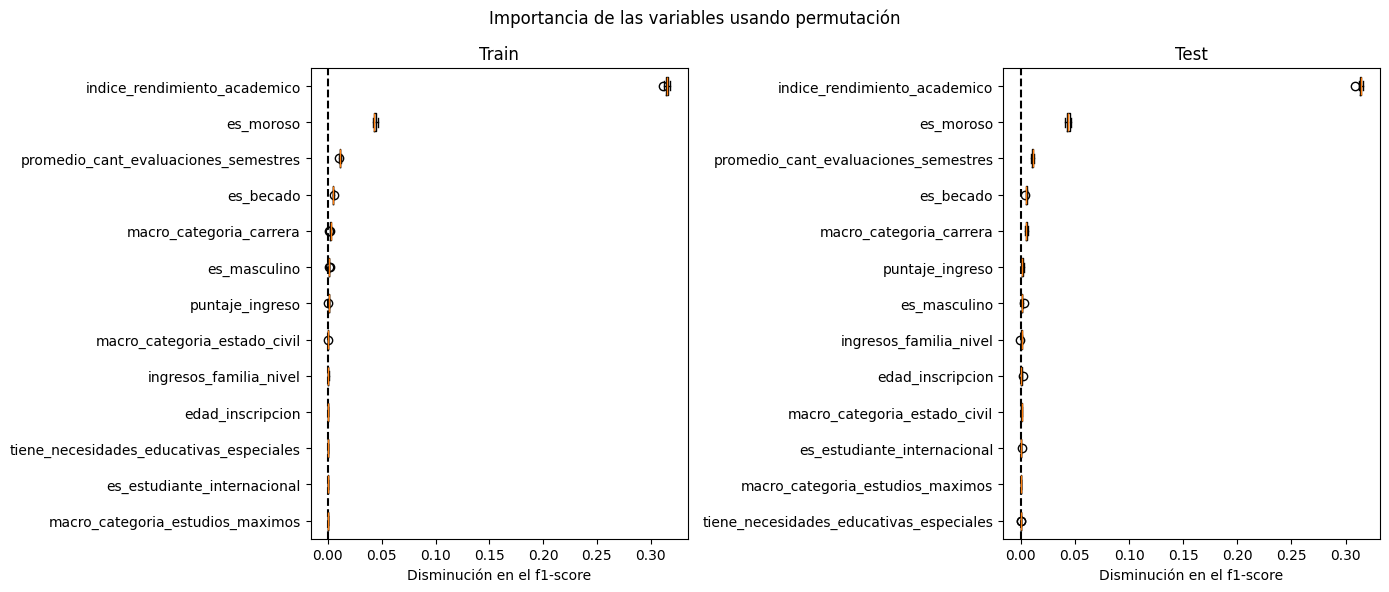

In [186]:
fig, (ax_train, ax_test) = plt.subplots(
    1, 2, figsize=(14, 6), sharey=False
)

plot_permutation_importance(classifier, X_train, y_train, ax_train)
ax_train.set_title("Train")
ax_train.set_xlabel("Disminución en el f1-score")

plot_permutation_importance(classifier, X_test, y_test, ax_test)
ax_test.set_title("Test")
ax_test.set_xlabel("Disminución en el f1-score")

fig.suptitle("Importancia de las variables usando permutación")
fig.tight_layout()
plt.show()

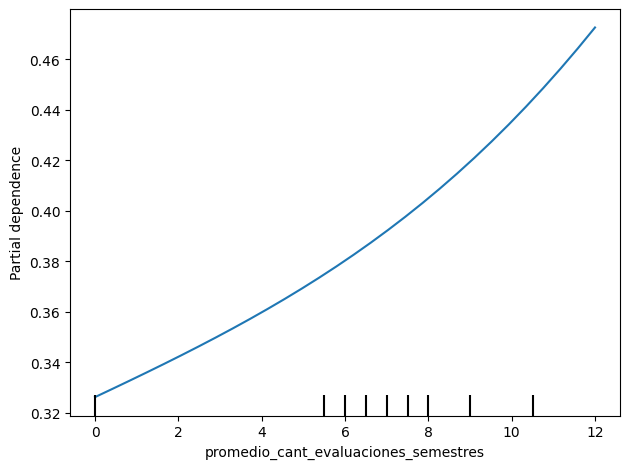

In [145]:
from sklearn.inspection import PartialDependenceDisplay

# modelo_pdp = lr_model["Logistic Regression"]
X_pdp = X_train.sample(n=min(5000, len(X_train)), random_state=42)

PartialDependenceDisplay.from_estimator(
    classifier,
    X_pdp,
    features=["promedio_cant_evaluaciones_semestres"],
    kind="average",
    response_method="predict_proba",
    grid_resolution=30,
)

plt.tight_layout()
plt.show()
